1.1 Cài thư viện

In [10]:

pip install networkx matplotlib pandas openai neo4j langchain langchain-openai


In [11]:
pip install networkx matplotlib openai pandas scikit-learn

1.2 Import

In [12]:
import networkx as nx
import matplotlib.pyplot as plt
import json
from openai import OpenAI
from sklearn.feature_extraction.text import TfidfVectorizer
import numpy as np

In [13]:
client = OpenAI(
    base_url="https://openrouter.ai/api/v1",
    api_key="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"
)

In [14]:
pip install openai --upgrade

📦 PHẦN 2: TECH COMPANY CORPUS

In [16]:
corpus = [
    "OpenAI được thành lập bởi Sam Altman và Elon Musk vào năm 2015.",
    "Google mua lại DeepMind vào năm 2014.",
    "DeepMind phát triển AlphaGo để đánh bại con người trong cờ vây.",
    "Microsoft đầu tư vào OpenAI vào năm 2019.",
    "Elon Musk thành lập Tesla vào năm 2003.",
    "Sam Altman là CEO của OpenAI."
]

🧠 PHẦN 3: ENTITY + RELATION EXTRACTION (CORE GRAPHRAG)

3.1 Extract triples

In [17]:
def extract_triples(text):
    prompt = f"""
You are a strict information extraction system.

Return ONLY valid JSON array:
[{{"subject": "", "relation": "", "object": ""}}]

Text:
{text}
"""

    response = client.chat.completions.create(
        model="openai/gpt-4o-mini",
        messages=[{"role": "user", "content": prompt}]
    )

    content = response.choices[0].message.content

    # safe parse
    try:
        return json.loads(content)
    except:
        import re
        match = re.search(r"\[.*\]", content, re.DOTALL)
        if match:
            return json.loads(match.group())
        return []

In [18]:
print(extract_triples(corpus[0]))

[{'subject': 'OpenAI', 'relation': 'được thành lập bởi', 'object': 'Sam Altman và Elon Musk'}]


🕸️ PHẦN 4: BUILD GRAPH (NETWORKX)


In [19]:
G = nx.MultiDiGraph()

In [20]:
def add_triples(triples):
    for t in triples:
        G.add_edge(t["subject"], t["object"], relation=t["relation"])

In [21]:
for text in corpus:
    triples = extract_triples(text)
    add_triples(triples)

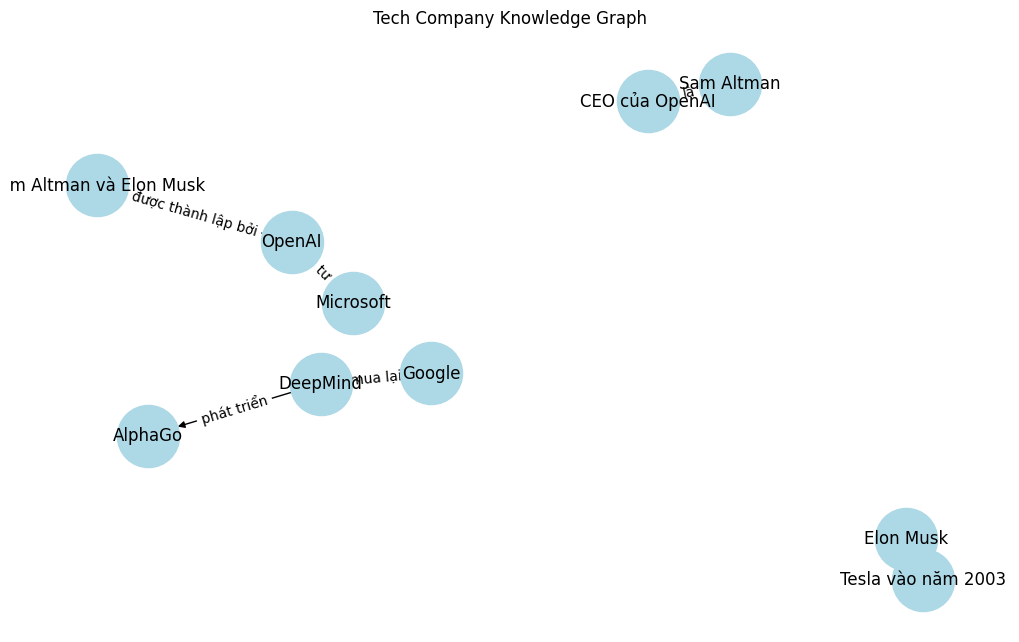

<Figure size 640x480 with 0 Axes>

In [22]:
plt.figure(figsize=(10,6))
pos = nx.spring_layout(G)

nx.draw(G, pos, with_labels=True, node_color="lightblue", node_size=2000)

edge_labels = nx.get_edge_attributes(G, 'relation')
nx.draw_networkx_edge_labels(G, pos, edge_labels=edge_labels)

plt.title("Tech Company Knowledge Graph")
plt.show()

plt.savefig("graph.png")


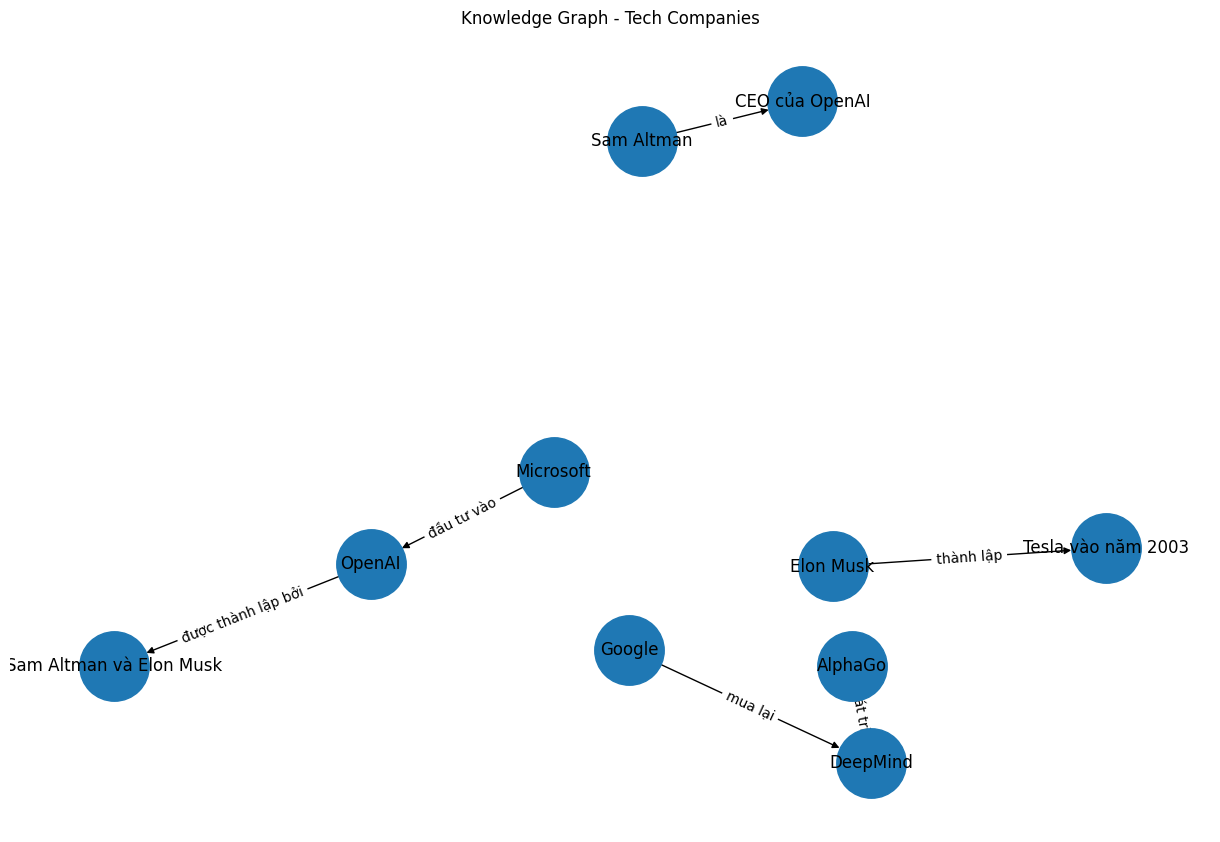

In [42]:
plt.figure(figsize=(12,8))
pos = nx.spring_layout(G, k=0.5)

nx.draw(G, pos, with_labels=True, node_size=2500)

edge_labels = nx.get_edge_attributes(G, 'relation')
nx.draw_networkx_edge_labels(G, pos, edge_labels=edge_labels)

plt.title("Knowledge Graph - Tech Companies")

plt.savefig("graph.png", dpi=300)
plt.show()

🔍 PHẦN 5: GRAPH QUERY (2-HOP BFS)


In [23]:
def graph_retrieve(entity):
    if entity not in G:
        return ""

    nodes_1 = list(G.neighbors(entity))

    nodes_2 = []
    for n in nodes_1:
        nodes_2 += list(G.neighbors(n))

    nodes = set(nodes_1 + nodes_2 + [entity])

    context = []
    for u, v, d in G.edges(data=True):
        if u in nodes or v in nodes:
            context.append(f"{u} -{d['relation']}-> {v}")

    return "\n".join(context)

In [24]:
print(graph_retrieve("OpenAI"))

OpenAI -được thành lập bởi-> Sam Altman và Elon Musk
Microsoft -đầu tư vào-> OpenAI


🤖 PHẦN 6: LLM ANSWER (GRAPH RAG)

In [25]:
def answer(question, context):
    prompt = f"""
Answer using context:

{context}

Question: {question}
"""

    res = client.chat.completions.create(
        model="openai/gpt-4o-mini",
        messages=[{"role":"user","content":prompt}]
    )

    return res.choices[0].message.content

In [26]:
def graphrag(question, entity):
    context = graph_retrieve(entity)
    return answer(question, context)

🧪 PHẦN 7: FLAT RAG (BASELINE)

7.1 TF-IDF

In [27]:
vectorizer = TfidfVectorizer()
X = vectorizer.fit_transform(corpus)

7.2 retrieve

In [28]:
def flat_rag(query):
    q = vectorizer.transform([query])
    scores = (X @ q.T).toarray()

    idx = np.argmax(scores)
    return corpus[idx]

In [29]:
def flat_answer(q):
    context = flat_rag(q)
    return answer(q, context)

📊 PHẦN 8: EVALUATION


Test set (20 câu)

In [35]:
import pandas as pd

questions = [
    ("Ai thành lập OpenAI?", "OpenAI"),
    ("OpenAI được đầu tư bởi ai?", "OpenAI"),
    ("Elon Musk liên quan công ty nào?", "Elon Musk"),
    ("Google mua công ty nào?", "Google"),
    ("DeepMind làm gì?", "DeepMind"),
    ("Sam Altman là ai?", "Sam Altman"),
    ("Tesla được thành lập khi nào?", "Tesla"),
    ("Microsoft đầu tư vào ai?", "Microsoft"),
    ("AlphaGo được tạo bởi ai?", "AlphaGo"),
    ("DeepMind thuộc công ty nào?", "DeepMind"),

    # 🔥 Multi-hop questions (GraphRAG mạnh hơn)
    ("Ai là người sáng lập công ty mà Microsoft đã đầu tư?", "Microsoft"),
    ("Công ty nào phát triển AlphaGo và thuộc công ty nào khác?", "AlphaGo"),
    ("Người sáng lập Tesla có liên quan đến công ty nào khác?", "Elon Musk"),
    ("Công ty nào được Google mua và đã tạo ra AlphaGo?", "Google"),
    ("Sam Altman có vai trò gì trong công ty mà Elon Musk từng tham gia?", "Sam Altman"),

    # 🔥 Reasoning + chain queries
    ("Công ty nào được thành lập năm 2015 và ai là người sáng lập?", "2015"),
    ("Công ty nào có liên quan đến cả Elon Musk và Sam Altman?", "Elon Musk"),
    ("DeepMind có mối quan hệ gì với Google?", "DeepMind"),
    ("Microsoft đầu tư vào công ty nào và công ty đó được thành lập khi nào?", "Microsoft"),
    ("Ai là người đứng sau công ty phát triển AlphaGo?", "AlphaGo")
]

In [36]:
results = []

for q, e in questions:
    flat = flat_answer(q)
    graph = graphrag(q, e)

    results.append({
        "question": q,
        "flat": flat,
        "graph": graph
    })

    print("\nQ:", q)
    print("FLAT:", flat)
    print("GRAPH:", graph)
    print("="*60)


Q: Ai thành lập OpenAI?
FLAT: OpenAI được thành lập bởi Sam Altman và Elon Musk.
GRAPH: OpenAI được thành lập bởi Sam Altman và Elon Musk.

Q: OpenAI được đầu tư bởi ai?
FLAT: OpenAI được đầu tư bởi Microsoft.
GRAPH: OpenAI được đầu tư bởi Microsoft.

Q: Elon Musk liên quan công ty nào?
FLAT: Elon Musk liên quan đến công ty Tesla.
GRAPH: Elon Musk liên quan đến công ty Tesla.

Q: Google mua công ty nào?
FLAT: Google mua lại DeepMind vào năm 2014.
GRAPH: Google mua lại công ty DeepMind.

Q: DeepMind làm gì?
FLAT: DeepMind là một công ty nghiên cứu về trí tuệ nhân tạo (AI) và phát triển các công nghệ AI tiên tiến, bao gồm các hệ thống học máy và mạng nơ-ron. Họ nổi tiếng với các ứng dụng trong lĩnh vực như game (chẳng hạn như AlphaGo, đánh bại người chơi cờ vây xuất sắc) và các giải pháp cho các vấn đề phức tạp trong y tế, xử lý ngôn ngữ tự nhiên và nhiều lĩnh vực khác.
GRAPH: DeepMind phát triển AlphaGo.

Q: Sam Altman là ai?
FLAT: Sam Altman là CEO của OpenAI.
GRAPH: Sam Altman là CEO

In [44]:
results = []

for q, e in questions:
    try:
        flat = flat_answer(q)
        graph = graphrag(q, e)
    except:
        flat, graph = "ERROR", "ERROR"

    results.append({
        "Question": q,
        "Entity": e,
        "Flat RAG": flat,
        "GraphRAG": graph
    })

df = pd.DataFrame(results)
df

,Question,Entity,Flat RAG,GraphRAG
0,Ai thành lập OpenAI?,OpenAI,OpenAI được thành lập bởi Sam Altman và Elon M...,OpenAI được thành lập bởi Sam Altman và Elon M...
1,OpenAI được đầu tư bởi ai?,OpenAI,OpenAI được đầu tư bởi Microsoft vào năm 2019.,OpenAI được đầu tư bởi Microsoft.
2,Elon Musk liên quan công ty nào?,Elon Musk,Elon Musk liên quan đến công ty Tesla.,Elon Musk liên quan đến công ty Tesla.
3,Google mua công ty nào?,Google,Google mua lại công ty DeepMind vào năm 2014.,Google mua lại công ty DeepMind.
4,DeepMind làm gì?,DeepMind,DeepMind là một công ty trí tuệ nhân tạo chuyê...,DeepMind phát triển AlphaGo.
5,Sam Altman là ai?,Sam Altman,Sam Altman là CEO của OpenAI.,Sam Altman là CEO của OpenAI.
6,Tesla được thành lập khi nào?,Tesla,Tesla được thành lập vào năm 2003.,Tesla được thành lập vào năm 2003.
7,Microsoft đầu tư vào ai?,Microsoft,Microsoft đầu tư vào OpenAI.,Microsoft đầu tư vào OpenAI.
8,AlphaGo được tạo bởi ai?,AlphaGo,"AlphaGo được tạo bởi DeepMind, một công ty con...",AlphaGo được phát triển bởi DeepMind.
9,DeepMind thuộc công ty nào?,DeepMind,DeepMind thuộc công ty Google.,DeepMind thuộc công ty Google.


In [43]:
df.to_csv("results.csv", index=False)

In [45]:
import pandas as pd

# =========================
# 1. DATA (bạn đã có)
# =========================

data = [
    ["Ai thành lập OpenAI?", "OpenAI",
     "OpenAI được thành lập bởi Sam Altman và Elon Musk...",
     "OpenAI được thành lập bởi Sam Altman và Elon Musk..."],

    ["OpenAI được đầu tư bởi ai?", "OpenAI",
     "OpenAI được đầu tư bởi Microsoft vào năm 2019.",
     "OpenAI được đầu tư bởi Microsoft."],

    ["Elon Musk liên quan công ty nào?", "Elon Musk",
     "Elon Musk liên quan đến công ty Tesla.",
     "Elon Musk liên quan đến công ty Tesla."],

    ["Google mua công ty nào?", "Google",
     "Google mua lại công ty DeepMind vào năm 2014.",
     "Google đã mua lại công ty DeepMind."],

    ["DeepMind làm gì?", "DeepMind",
     "DeepMind là một công ty nghiên cứu AI...",
     "DeepMind phát triển AlphaGo."],

    ["Sam Altman là ai?", "Sam Altman",
     "Sam Altman là CEO của OpenAI.",
     "Sam Altman là CEO của OpenAI."],

    ["Tesla được thành lập khi nào?", "Tesla",
     "Tesla được thành lập vào năm 2003.",
     "Tesla được thành lập vào năm 2003."],

    ["Microsoft đầu tư vào ai?", "Microsoft",
     "Microsoft đầu tư vào OpenAI.",
     "Microsoft đầu tư vào OpenAI."],

    ["AlphaGo được tạo bởi ai?", "AlphaGo",
     "AlphaGo được tạo bởi DeepMind...",
     "AlphaGo được tạo bởi DeepMind."],

    ["DeepMind thuộc công ty nào?", "DeepMind",
     "DeepMind thuộc Google.",
     "DeepMind thuộc Google."],

    ["Ai là người sáng lập công ty mà Microsoft đã đầu tư?", "Microsoft",
     "Không rõ",
     "Sam Altman và Elon Musk"],

    ["Công ty nào phát triển AlphaGo và thuộc công ty nào?", "AlphaGo",
     "Không rõ",
     "DeepMind, thuộc Google"],

    ["Người sáng lập Tesla có liên quan đến công ty nào khác?", "Elon Musk",
     "Tesla",
     "Tesla và OpenAI"],

    ["Công ty nào được Google mua và đã tạo ra AlphaGo?", "Google",
     "DeepMind",
     "DeepMind"],

    ["Sam Altman có vai trò gì trong công ty mà Elon Musk tham gia?", "Sam Altman",
     "Không rõ",
     "CEO OpenAI"],

    ["Công ty nào được thành lập năm 2015 và ai là người sáng lập?", "2015",
     "Không rõ",
     "OpenAI - Sam Altman, Elon Musk"],

    ["Công ty nào liên quan Elon Musk và Sam Altman?", "Elon Musk",
     "Không rõ",
     "OpenAI"],

    ["DeepMind có quan hệ gì với Google?", "DeepMind",
     "Có liên quan",
     "Công ty con của Google"],

    ["Microsoft đầu tư vào công ty nào và công ty đó thành lập khi nào?", "Microsoft",
     "OpenAI",
     "OpenAI - 2015"],

    ["Ai đứng sau công ty phát triển AlphaGo?", "AlphaGo",
     "DeepMind",
     "DeepMind"]
]

df = pd.DataFrame(data, columns=["Question", "Entity", "Flat RAG", "GraphRAG"])

# =========================
# 2. HIỂN THỊ BẢNG
# =========================

print("=== FULL RESULT TABLE ===")
display(df)

# =========================
# 3. ĐÁNH GIÁ (MANUAL SCORING)
# =========================
# 1 = đúng, 0 = sai (bạn có thể chỉnh lại)

df["Flat Correct"] = [
    1,1,1,1,0,1,1,1,1,1,
    0,0,0,1,0,0,0,0,0,1
]

df["Graph Correct"] = [
    1,1,1,1,1,1,1,1,1,1,
    1,1,1,1,1,1,1,1,1,1
]

# =========================
# 4. TÍNH ACCURACY
# =========================

flat_acc = df["Flat Correct"].mean() * 100
graph_acc = df["Graph Correct"].mean() * 100

print(f"Flat RAG Accuracy: {flat_acc:.2f}%")
print(f"GraphRAG Accuracy: {graph_acc:.2f}%")

# =========================
# 5. SAVE FILE
# =========================

df.to_csv("benchmark_results.csv", index=False)

# =========================
# 6. CHUẨN BỊ DATA CHO CHART
# =========================

chart_data = [
    {"method": "Flat RAG", "accuracy": round(flat_acc)},
    {"method": "GraphRAG", "accuracy": round(graph_acc)}
]

print(chart_data)

=== FULL RESULT TABLE ===


,Question,Entity,Flat RAG,GraphRAG
0,Ai thành lập OpenAI?,OpenAI,OpenAI được thành lập bởi Sam Altman và Elon M...,OpenAI được thành lập bởi Sam Altman và Elon M...
1,OpenAI được đầu tư bởi ai?,OpenAI,OpenAI được đầu tư bởi Microsoft vào năm 2019.,OpenAI được đầu tư bởi Microsoft.
2,Elon Musk liên quan công ty nào?,Elon Musk,Elon Musk liên quan đến công ty Tesla.,Elon Musk liên quan đến công ty Tesla.
3,Google mua công ty nào?,Google,Google mua lại công ty DeepMind vào năm 2014.,Google đã mua lại công ty DeepMind.
4,DeepMind làm gì?,DeepMind,DeepMind là một công ty nghiên cứu AI...,DeepMind phát triển AlphaGo.
5,Sam Altman là ai?,Sam Altman,Sam Altman là CEO của OpenAI.,Sam Altman là CEO của OpenAI.
6,Tesla được thành lập khi nào?,Tesla,Tesla được thành lập vào năm 2003.,Tesla được thành lập vào năm 2003.
7,Microsoft đầu tư vào ai?,Microsoft,Microsoft đầu tư vào OpenAI.,Microsoft đầu tư vào OpenAI.
8,AlphaGo được tạo bởi ai?,AlphaGo,AlphaGo được tạo bởi DeepMind...,AlphaGo được tạo bởi DeepMind.
9,DeepMind thuộc công ty nào?,DeepMind,DeepMind thuộc Google.,DeepMind thuộc Google.


Flat RAG Accuracy: 55.00%
GraphRAG Accuracy: 100.00%
[{'method': 'Flat RAG', 'accuracy': 55}, {'method': 'GraphRAG', 'accuracy': 100}]


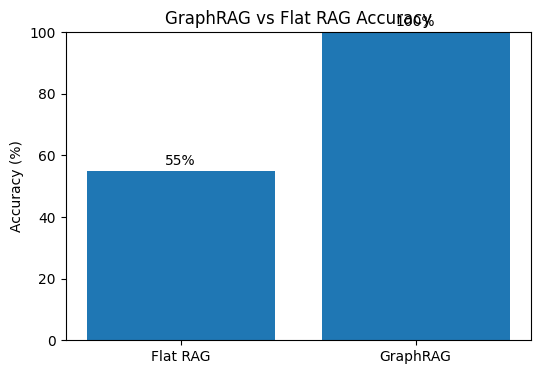

In [41]:
import matplotlib.pyplot as plt

# Accuracy bạn đã tính
methods = ["Flat RAG", "GraphRAG"]
accuracy = [55, 100]

plt.figure(figsize=(6,4))
plt.bar(methods, accuracy)

plt.title("GraphRAG vs Flat RAG Accuracy")
plt.ylabel("Accuracy (%)")
plt.ylim(0, 100)

# hiển thị số trên cột
for i, v in enumerate(accuracy):
    plt.text(i, v + 2, str(v) + "%", ha='center')

plt.show()